<a href="https://colab.research.google.com/github/tharun0210/Bank-Customer-Churn-Risk-Predictor-project-1/blob/main/bank_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [1]:
# Install required libraries
!pip install xgboost shap imbalanced-learn --quiet

In [2]:
# ── Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [4]:
# ── Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [5]:
# ── Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


In [6]:
# ── Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)


In [7]:
# ── Explainability
import shap
shap.initjs()

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [8]:
from google.colab import files
uploaded = files.upload()          # browse to European_Bank.csv
import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

Saving European_Bank.csv to European_Bank.csv


In [9]:

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
print('=== Data Types ===')
print(df_raw.dtypes)

=== Data Types ===
Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [11]:
print('\n=== Missing Values ===')
print(df_raw.isnull().sum())


=== Missing Values ===
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [12]:
print('\n=== Duplicate Rows ===')
print(df_raw.duplicated().sum())


=== Duplicate Rows ===
0


In [13]:
# ── Statistical summary ───────────────────────────────────────────────────────
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,10000.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


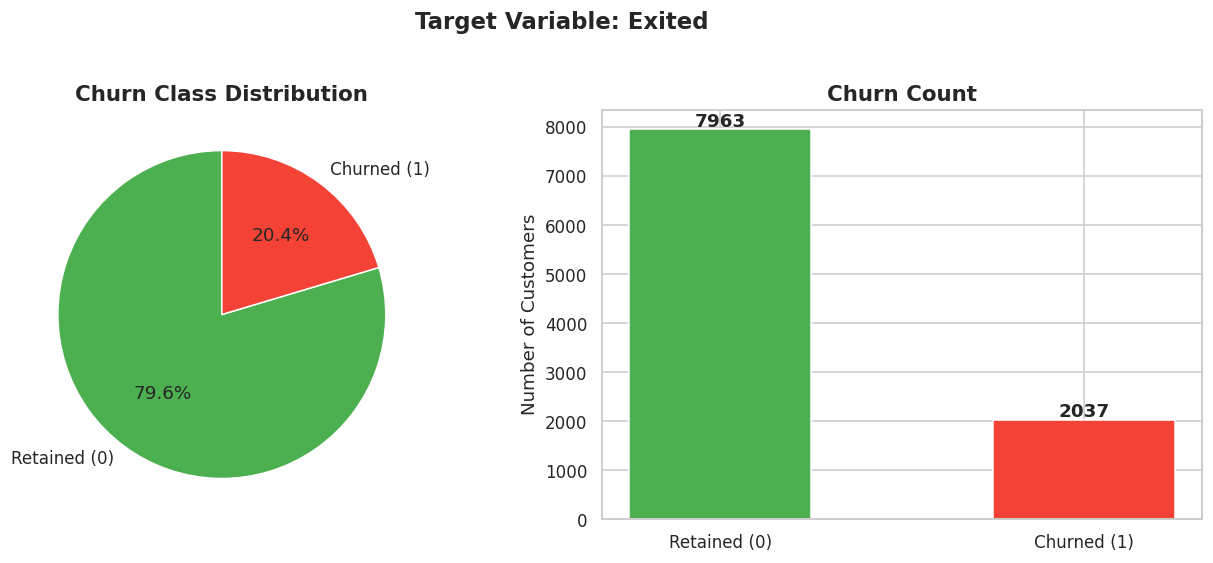

Churn Rate: 20.37%


In [14]:
# Churn Distribution
churn_counts = df_raw['Exited'].value_counts()
labels = ['Retained (0)', 'Churned (1)']
colors = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(churn_counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Churn Class Distribution', fontsize=14, fontweight='bold')

axes[1].bar(labels, churn_counts.values, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Target Variable: Exited', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Churn Rate: {churn_counts[1] / len(df_raw) * 100:.2f}%')

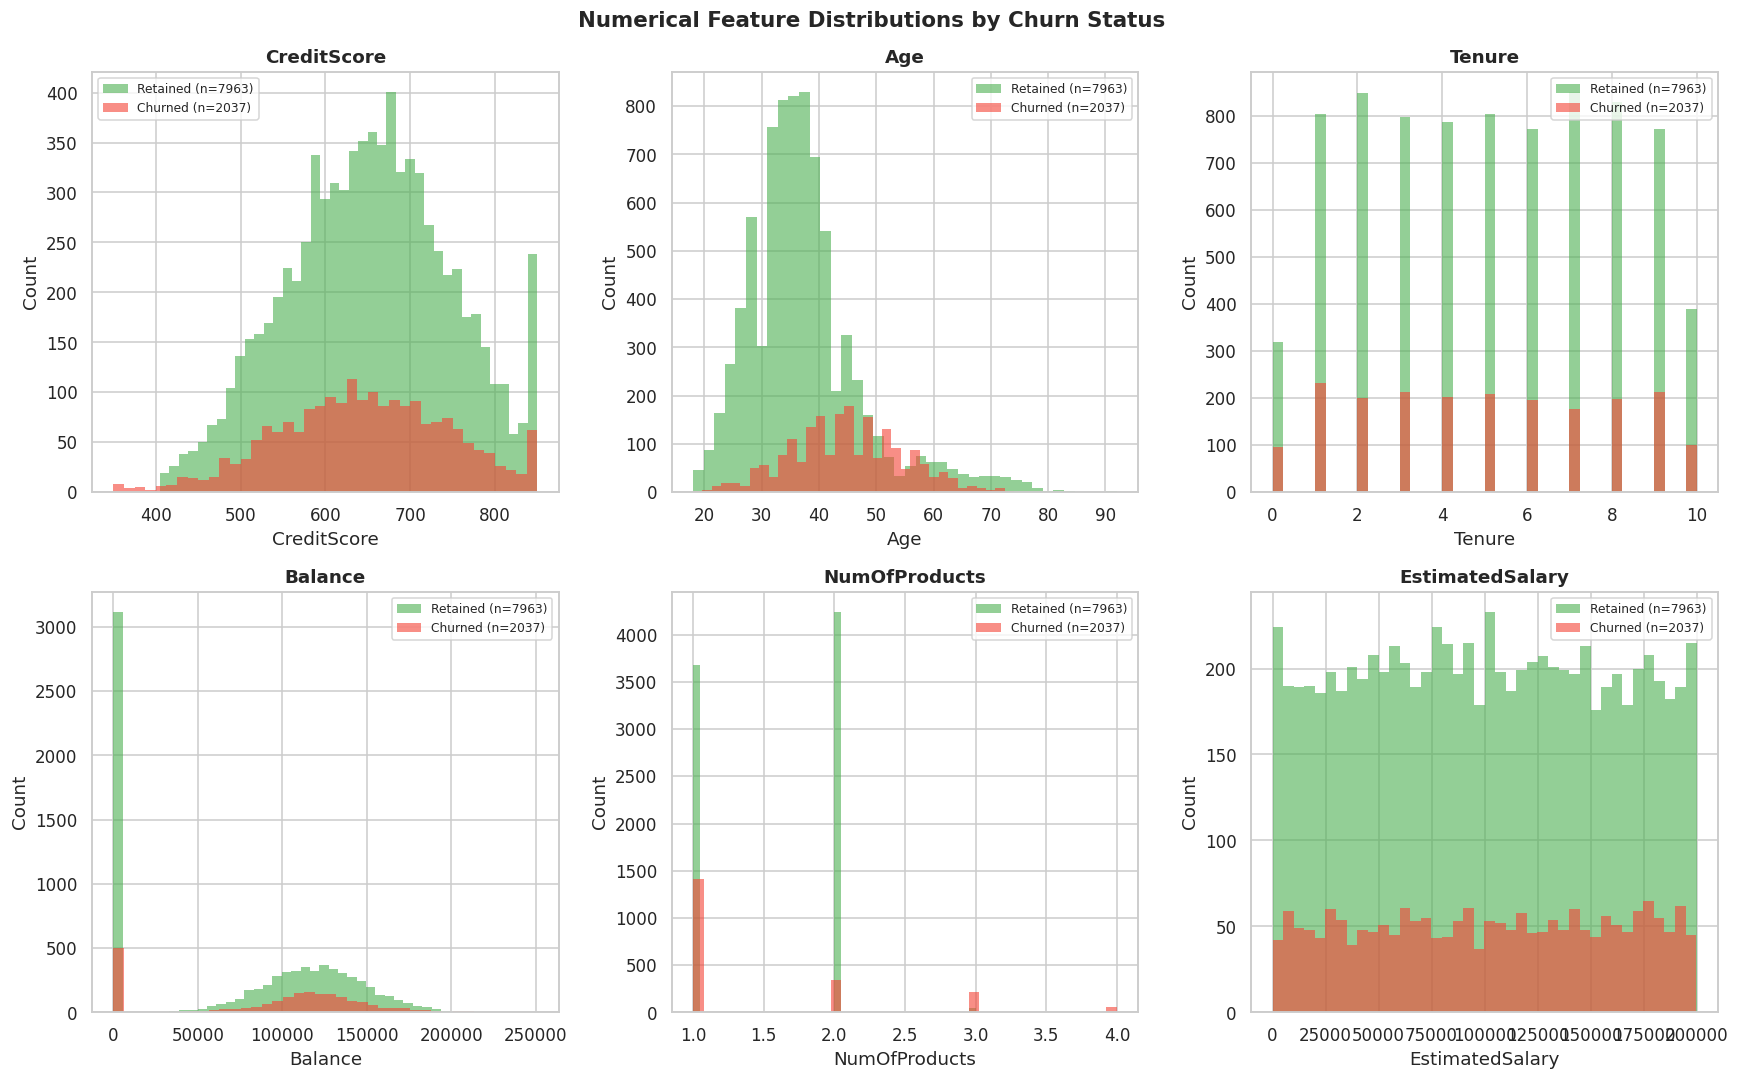

In [15]:
#  Numerical Feature Distributions
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
        subset = df_raw[df_raw['Exited'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label=f'{"Retained" if label==0 else "Churned"} (n={len(subset)})',
                     edgecolor='none')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

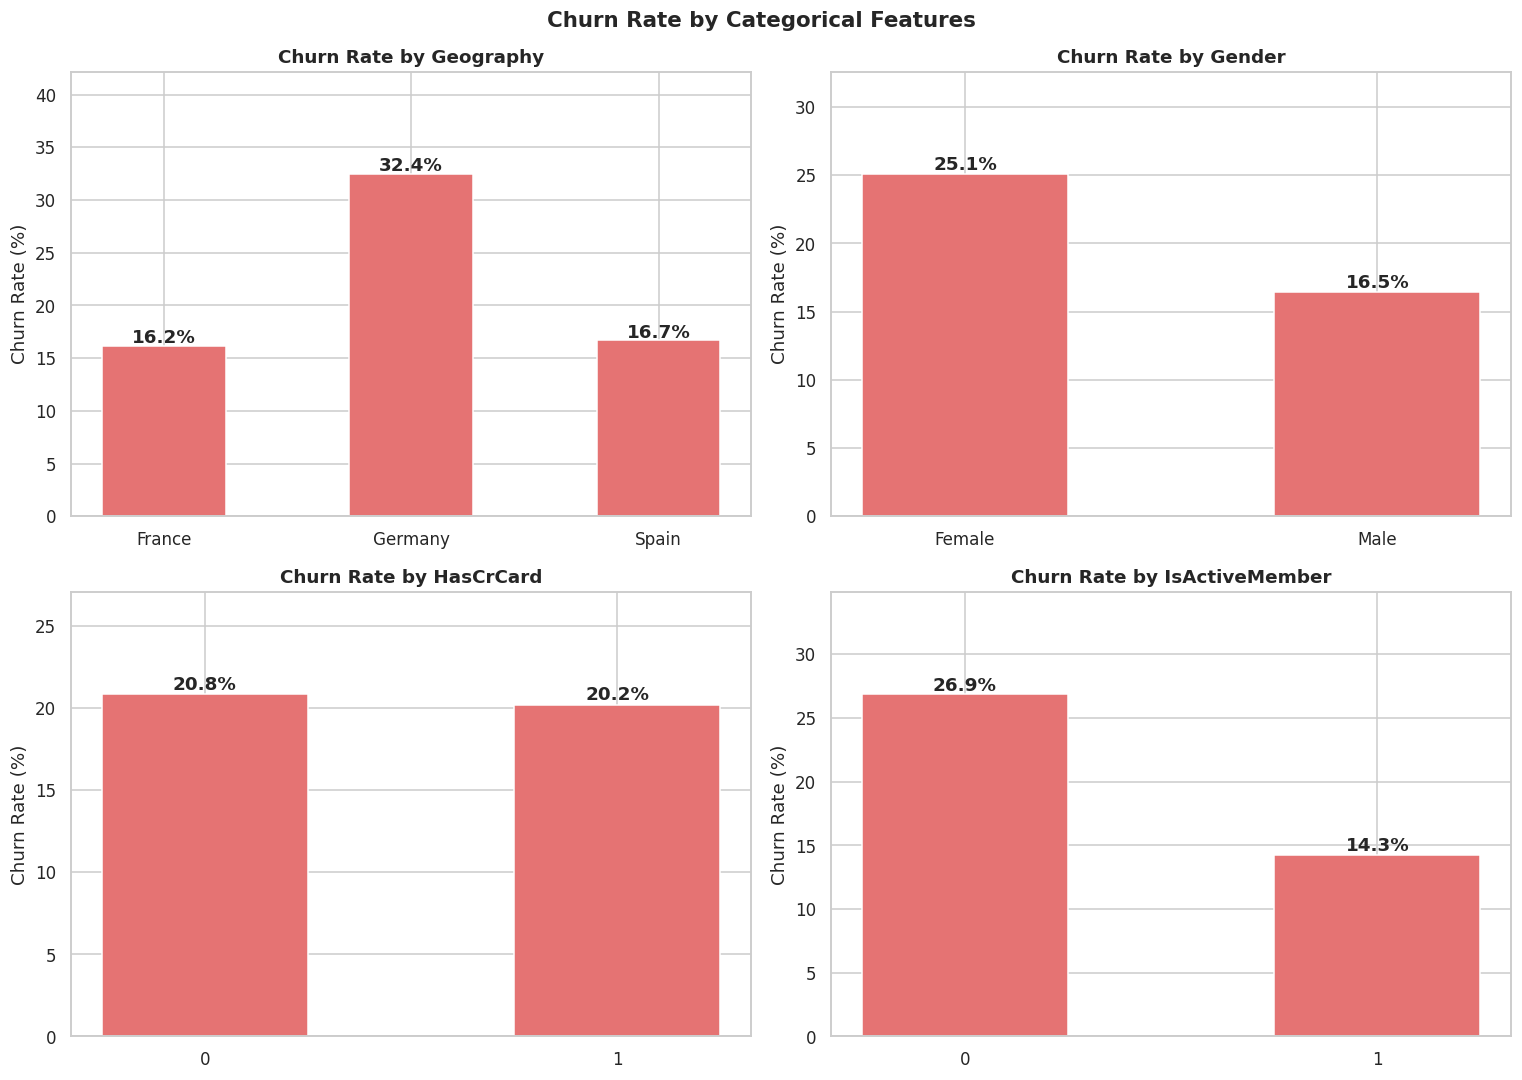

In [16]:
#   Categorical Feature Analysis
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df_raw.groupby(col)['Exited'].mean().reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate['ChurnRate'] = churn_rate['ChurnRate'] * 100

    bars = axes[i].bar(churn_rate[col].astype(str),
                       churn_rate['ChurnRate'],
                       color='#E57373', edgecolor='white', width=0.5)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, churn_rate['ChurnRate'].max() * 1.3)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f'{h:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

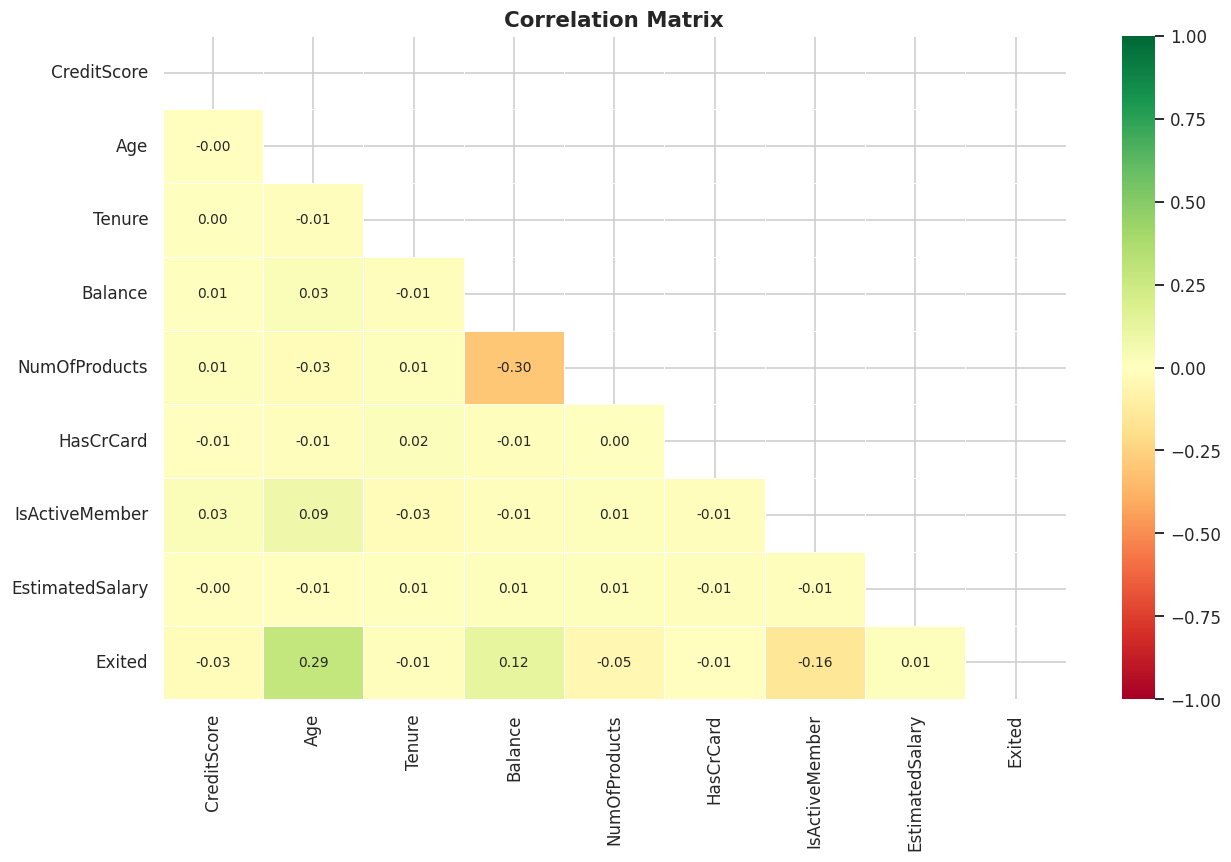

In [17]:
#  Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
             'NumOfProducts', 'HasCrCard', 'IsActiveMember',
             'EstimatedSalary', 'Exited']
corr = df_raw[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

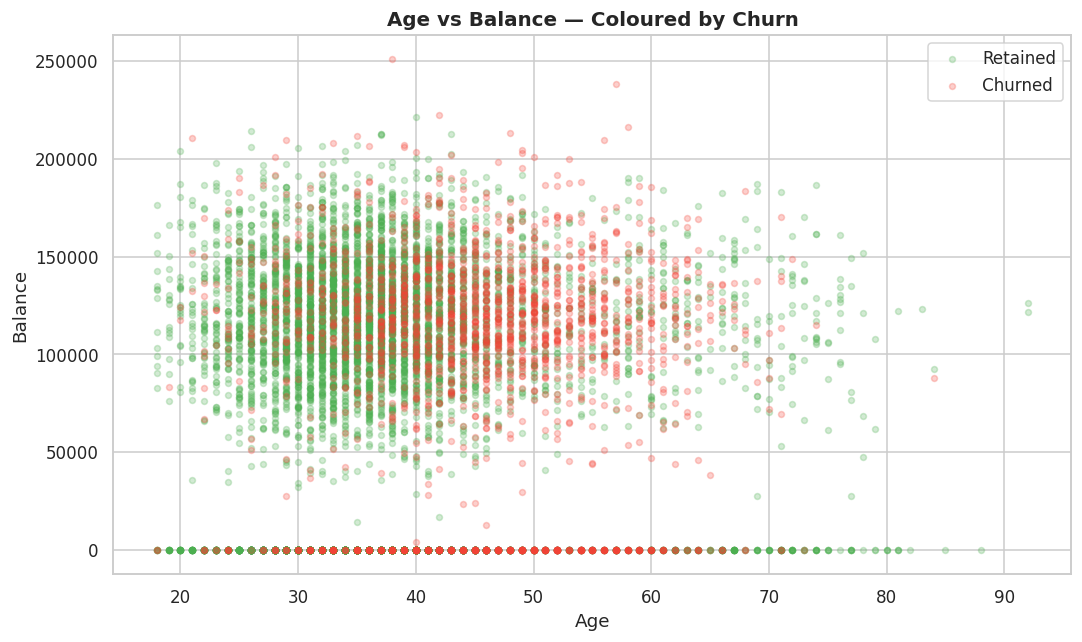

In [18]:
# Age vs Balance scatter by Churn
fig, ax = plt.subplots(figsize=(10, 6))
for label, color, name in zip([0, 1], ['#4CAF50', '#F44336'], ['Retained', 'Churned']):
    subset = df_raw[df_raw['Exited'] == label]
    ax.scatter(subset['Age'], subset['Balance'], alpha=0.25,
               c=color, label=name, s=15)
ax.set_xlabel('Age')
ax.set_ylabel('Balance')
ax.set_title('Age vs Balance — Coloured by Churn', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

data processiing

In [19]:
# Drop non-informative columns
df = df_raw.drop(columns=['CustomerId', 'Surname', 'Year'], errors='ignore').copy()
print('Columns after drop:', df.columns.tolist())

Columns after drop: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [20]:
# Handle missing values (there are none here, but kept for robustness)
df.fillna(df.median(numeric_only=True), inplace=True)   # numeric
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)      # categorical

print('Missing after imputation:', df.isnull().sum().sum())

Missing after imputation: 0


In [21]:
#  One-hot encode Geography & Gender
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=False)
print('\nColumns after encoding:', df.columns.tolist())
df.shape


Columns after encoding: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


(10000, 14)

feature engineering

---



In [22]:

# Balance-to-Salary ratio (wealth indicator)
df['BalanceToSalary'] = df['Balance'] / (df['EstimatedSalary'] + 1)


In [23]:
# Zero balance flag
df['ZeroBalance'] = (df['Balance'] == 0).astype(int)

In [24]:
# Product density: products per tenure year
df['ProductsPerYear'] = df['NumOfProducts'] / (df['Tenure'] + 1)


In [25]:
# Engagement-product interaction
df['EngagementProducts'] = df['IsActiveMember'] * df['NumOfProducts']

In [26]:
# Age × Tenure interaction (loyalty-by-age)
df['AgeTenure'] = df['Age'] * df['Tenure']


In [27]:
# CreditScore band
df['CreditScorePerAge'] = df['CreditScore'] / df['Age']


In [28]:

print('Feature-engineered columns added:')
new_feats = ['BalanceToSalary', 'ZeroBalance', 'ProductsPerYear',
             'EngagementProducts', 'AgeTenure', 'CreditScorePerAge']
print(df[new_feats].describe().T.round(3))

Feature-engineered columns added:
                      count     mean      std    min     25%      50%  \
BalanceToSalary     10000.0    3.790  100.056  0.000   0.000    0.747   
ZeroBalance         10000.0    0.362    0.481  0.000   0.000    0.000   
ProductsPerYear     10000.0    0.367    0.338  0.091   0.167    0.250   
EngagementProducts  10000.0    0.791    0.870  0.000   0.000    1.000   
AgeTenure           10000.0  194.804  127.940  0.000  90.000  180.000   
CreditScorePerAge   10000.0   17.874    5.376  4.857  14.089   17.286   

                        75%       max  
BalanceToSalary       1.514  9770.883  
ZeroBalance           1.000     1.000  
ProductsPerYear       0.500     3.000  
EngagementProducts    2.000     4.000  
AgeTenure           280.000   880.000  
CreditScorePerAge    20.962    46.889  


In [29]:
#  Split
X = df.drop(columns=['Exited'])
y = df['Exited']

# Save feature names for SHAP plots later
FEATURE_NAMES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train churn: {y_train.mean()*100:.2f}% | Test churn: {y_test.mean()*100:.2f}%')


Train size : 8000 | Test size: 2000
Train churn: 20.38% | Test churn: 20.35%


In [30]:
#  Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE (handle class imbalance for logistic regression)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f'\nAfter SMOTE — class distribution:')
print(pd.Series(y_train_sm).value_counts())


After SMOTE — class distribution:
Exited
1    6370
0    6370
Name: count, dtype: int64


In [31]:
#  Defining  all models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, C=0.5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=10,
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=5, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=5, use_label_encoder=False,
                                           eval_metric='logloss', random_state=42,
                                           n_jobs=-1),
}


In [32]:
#  Train all models
trained = {}
print('Training models...')
for name, model in models.items():
    # Logistic Regression uses SMOTE-balanced data; rest use raw (tree-based are robust)
    if name == 'Logistic Regression':
        model.fit(X_train_sm, y_train_sm)
    else:
        model.fit(X_train, y_train)          # tree models handle imbalance natively
    trained[name] = model
    print(f'  ✓ {name}')

print('\n✅ All models trained!')

Training models...
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ XGBoost

✅ All models trained!


In [33]:
#  Evaluation helper
def evaluate(name, model, X_eval, y_eval, use_scaled=False):
    Xev = X_test_sc if use_scaled else X_eval
    y_pred = model.predict(Xev)
    y_prob = model.predict_proba(Xev)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_eval, y_pred), 4),
        'Precision': round(precision_score(y_eval, y_pred), 4),
        'Recall'   : round(recall_score(y_eval, y_pred), 4),
        'F1'       : round(f1_score(y_eval, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_eval, y_prob), 4),
    }

In [34]:
# Collect results
results = []
for name, model in trained.items():
    use_sc = (name == 'Logistic Regression')
    results.append(evaluate(name, model, X_test, y_test, use_scaled=use_sc))

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('=== Model Comparison ===')
results_df

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.869,0.7866,0.4889,0.6030,0.8639
1,Gradient Boosting,0.870,0.7860,0.4963,0.6084,0.8638
2,Random Forest,0.865,0.7890,0.4595,0.5807,0.8600
3,Decision Tree,0.859,0.7729,0.4349,0.5566,0.8385
4,Logistic Regression,0.702,0.3774,0.7150,0.4941,0.7787


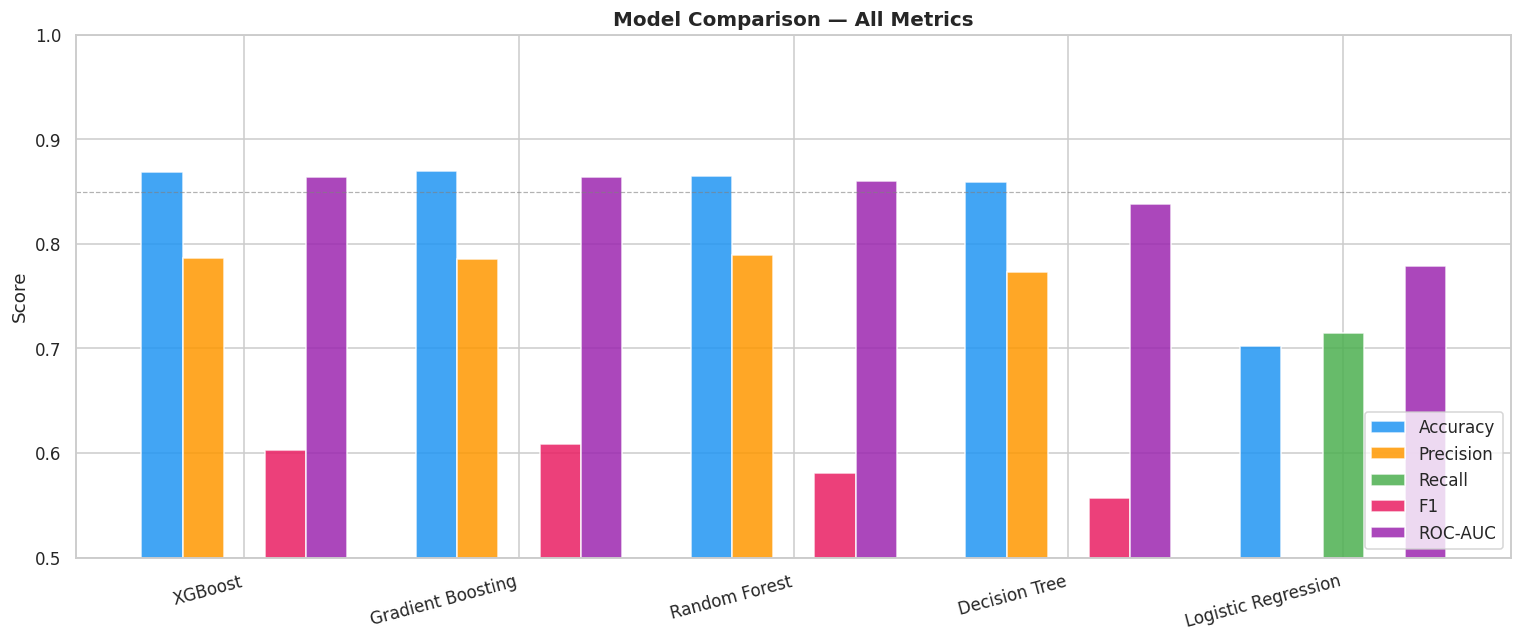

In [35]:
#  Metric bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors_bar = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.85, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

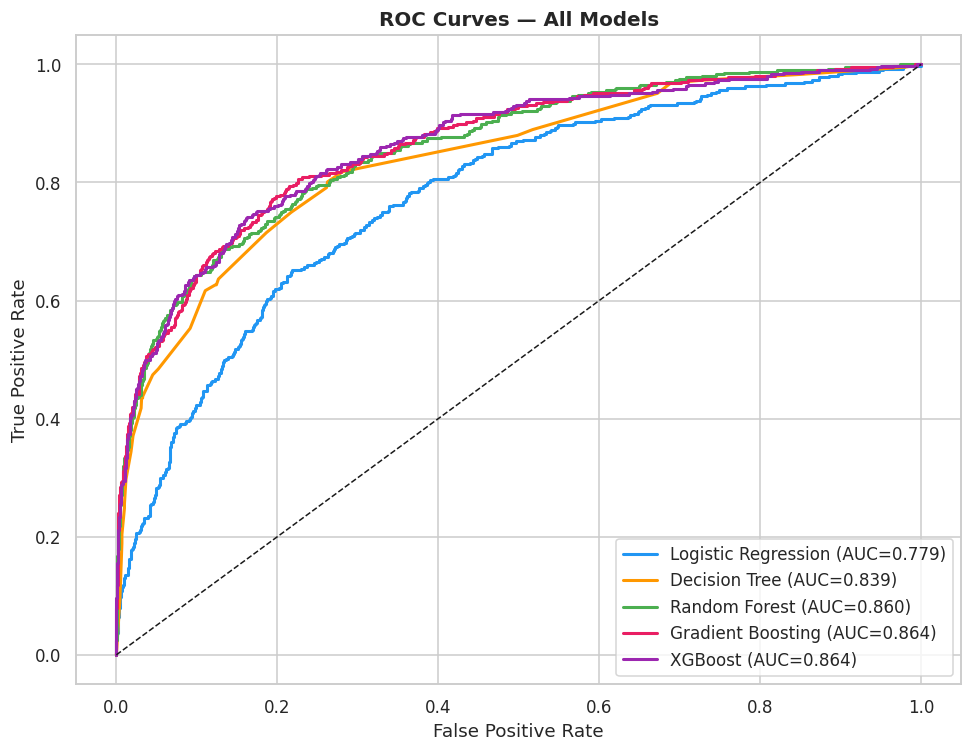

In [36]:
#  ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

for (name, model), color in zip(trained.items(), colors_roc):
    Xev = X_test_sc if name == 'Logistic Regression' else X_test
    y_prob = model.predict_proba(Xev)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

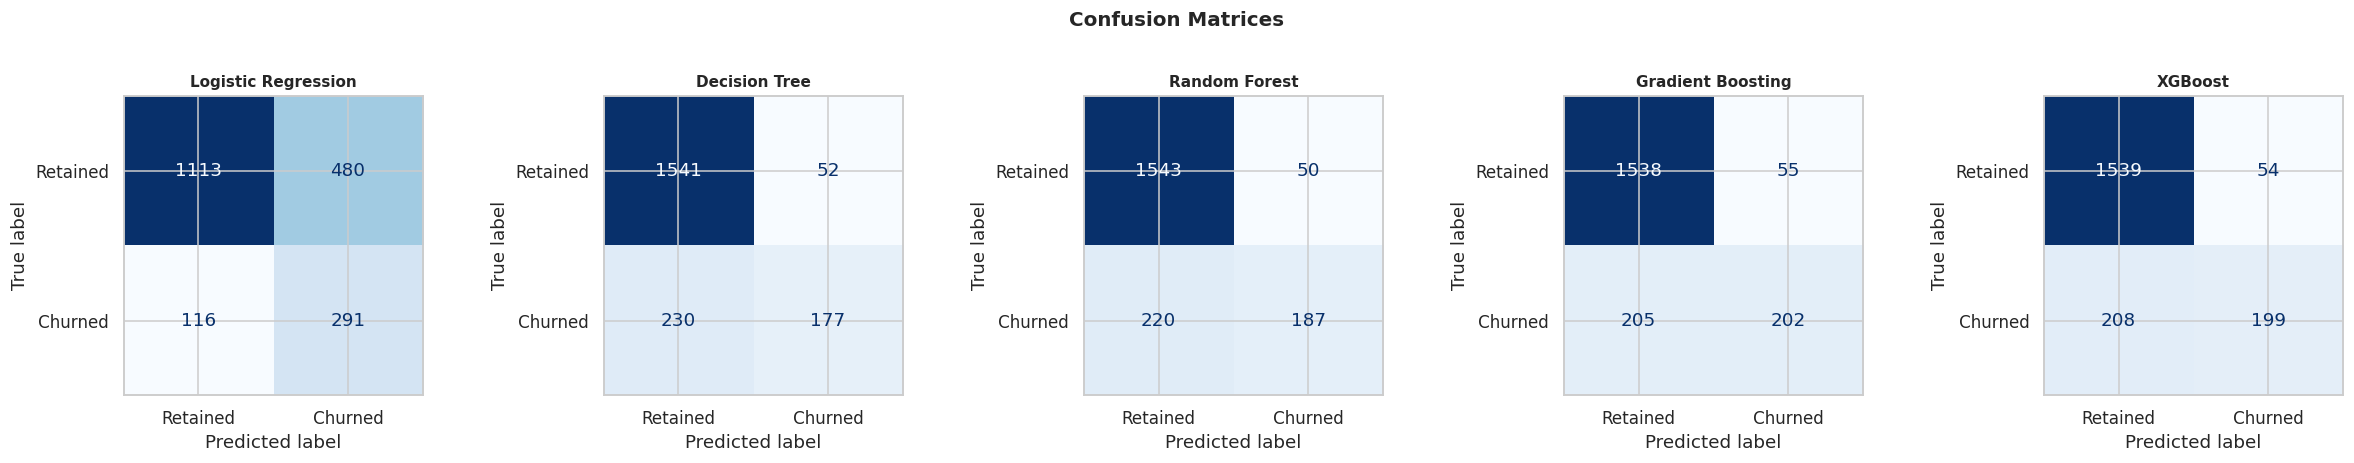

In [37]:
# Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, trained.items()):
    Xev = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(Xev)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [38]:
# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained[best_model_name]
print(f'🏆 Best Model: {best_model_name}')
print(results_df.iloc[0])

🏆 Best Model: XGBoost
Model        XGBoost
Accuracy       0.869
Precision     0.7866
Recall        0.4889
F1             0.603
ROC-AUC       0.8639
Name: 0, dtype: object


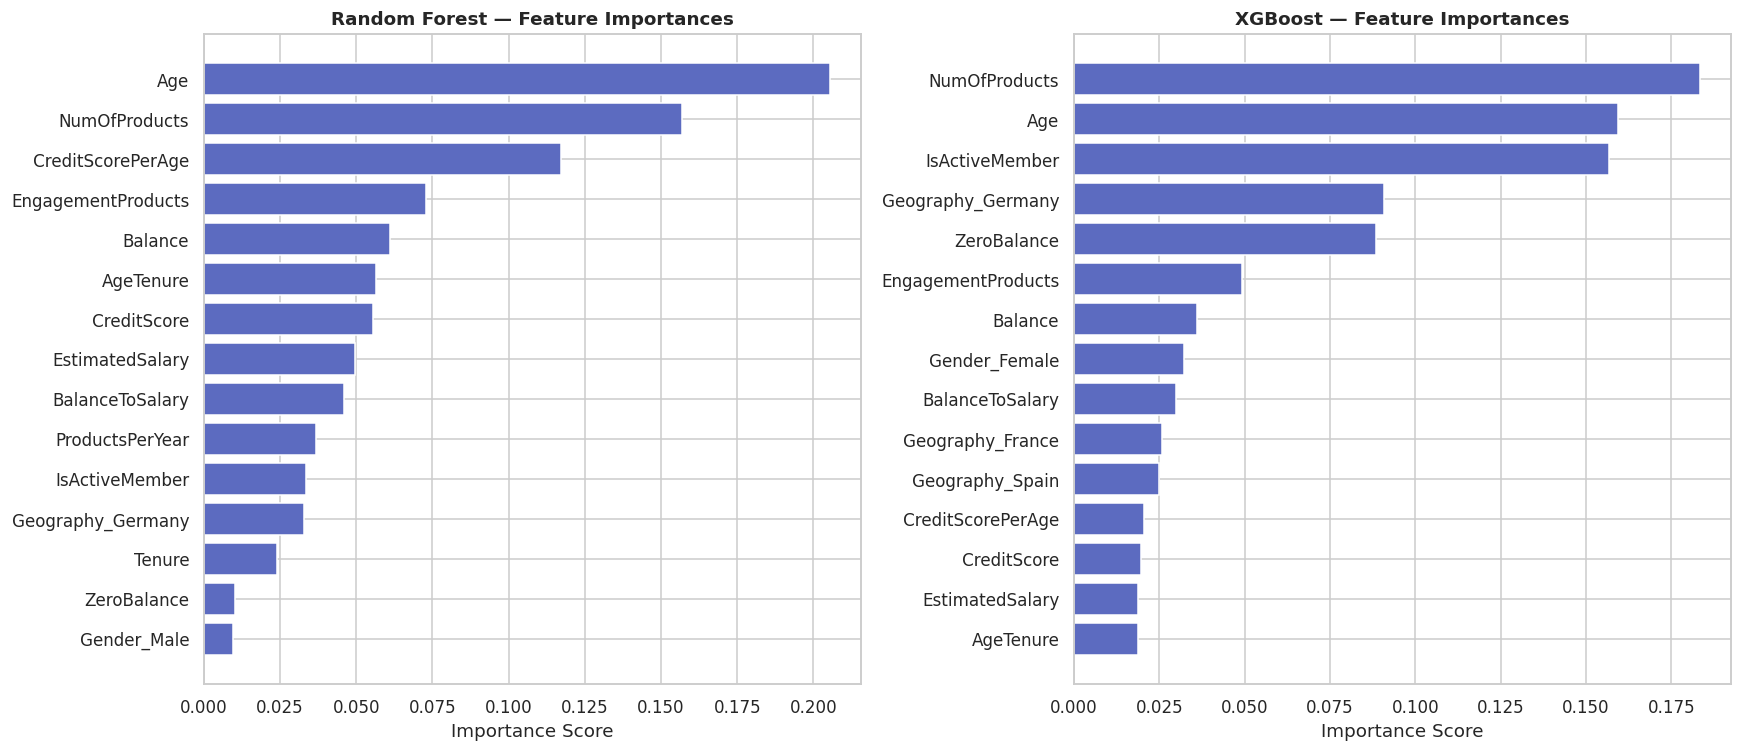

In [39]:
# Feature Importance — Random Forest & XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained[model_name]
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': FEATURE_NAMES, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

    ax.barh(fi_df['Feature'], fi_df['Importance'],
            color='#5C6BC0', edgecolor='white')
    ax.set_title(f'{model_name} — Feature Importances', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

SHAP values computed for 2000 test samples.


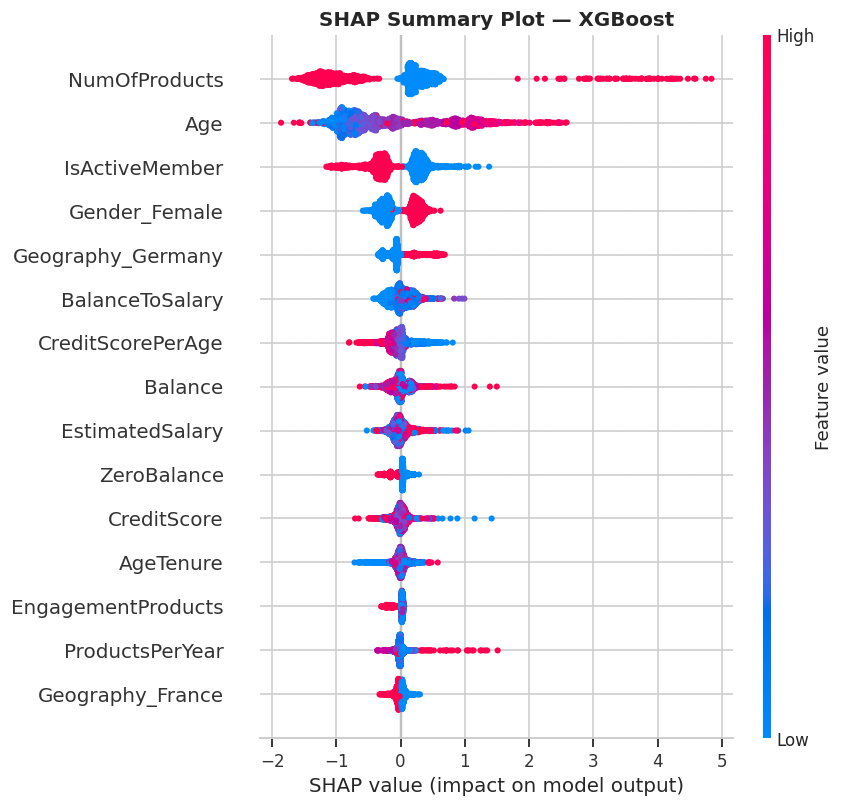

In [40]:
#  SHAP Analysis
# Using XGBoost (fastest SHAP support)
xgb_model = trained['XGBoost']

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print('SHAP values computed for', len(X_test), 'test samples.')

# Summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_NAMES, max_display=15, show=False)
plt.title('SHAP Summary Plot — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

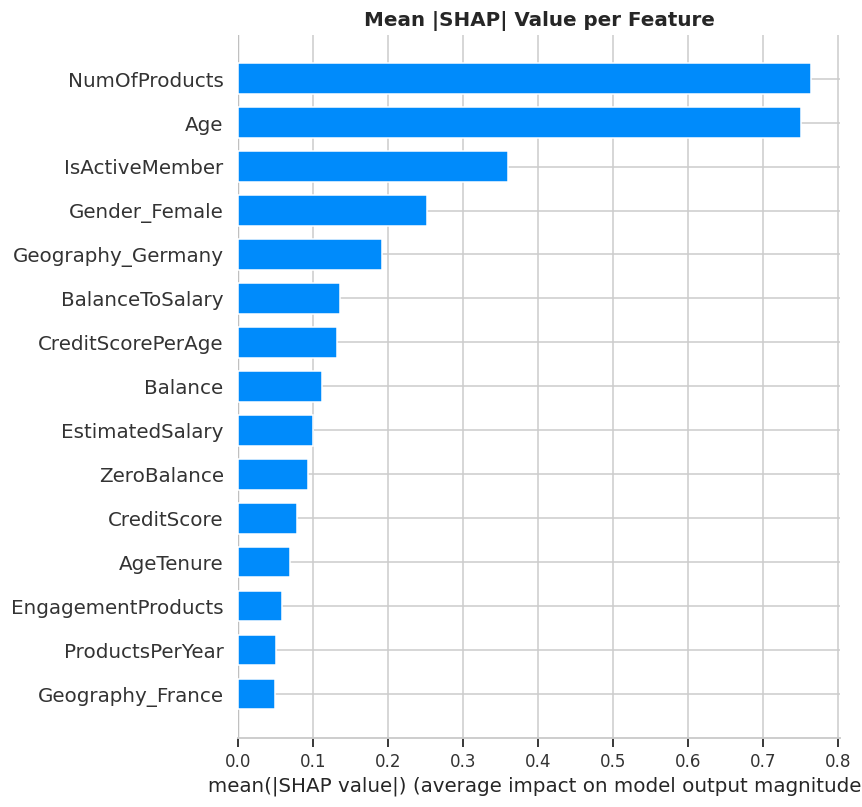

In [41]:
#  SHAP Bar Plot (mean absolute)
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_NAMES,
                  plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP| Value per Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

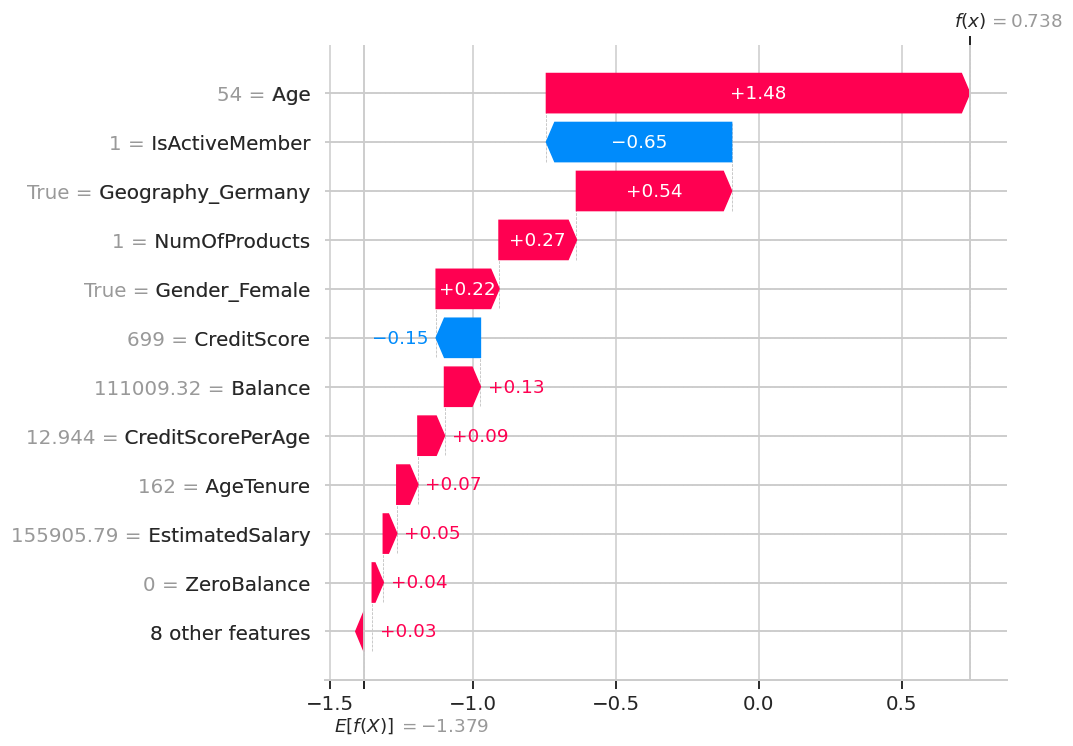

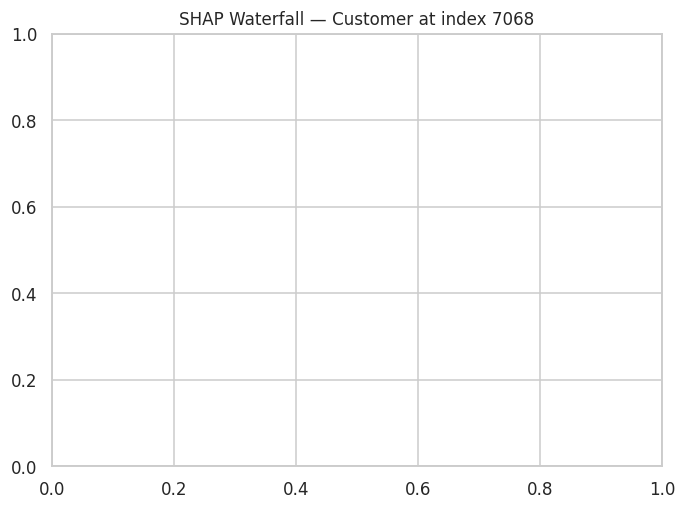

In [42]:
#  SHAP Waterfall — single customer
# Inspect the first churned customer in test set
churned_idx = y_test[y_test == 1].index[0]
row_pos = list(X_test.index).index(churned_idx)

shap.waterfall_plot(
    shap.Explanation(values=shap_values[row_pos],
                     base_values=explainer.expected_value,
                     data=X_test.iloc[row_pos].values,
                     feature_names=FEATURE_NAMES),
    max_display=12
)
plt.title(f'SHAP Waterfall — Customer at index {churned_idx}', fontsize=11)
plt.tight_layout()
plt.show()

churn rish scoring

In [43]:
# Generating probability scores
churn_probs = best_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['ChurnProbability'] = churn_probs
risk_df['ActualChurn']      = y_test.values
risk_df['PredictedChurn']   = best_model.predict(X_test)


In [44]:
#  Risk tiers
def risk_tier(prob):
    if prob >= 0.75:  return '🔴 High'
    elif prob >= 0.50: return '🟠 Medium-High'
    elif prob >= 0.30: return '🟡 Medium'
    else:              return '🟢 Low'

risk_df['RiskTier'] = risk_df['ChurnProbability'].apply(risk_tier)
print('Risk tier distribution:')
print(risk_df['RiskTier'].value_counts())

Risk tier distribution:
RiskTier
🟢 Low            1552
🟡 Medium          195
🔴 High            129
🟠 Medium-High     124
Name: count, dtype: int64


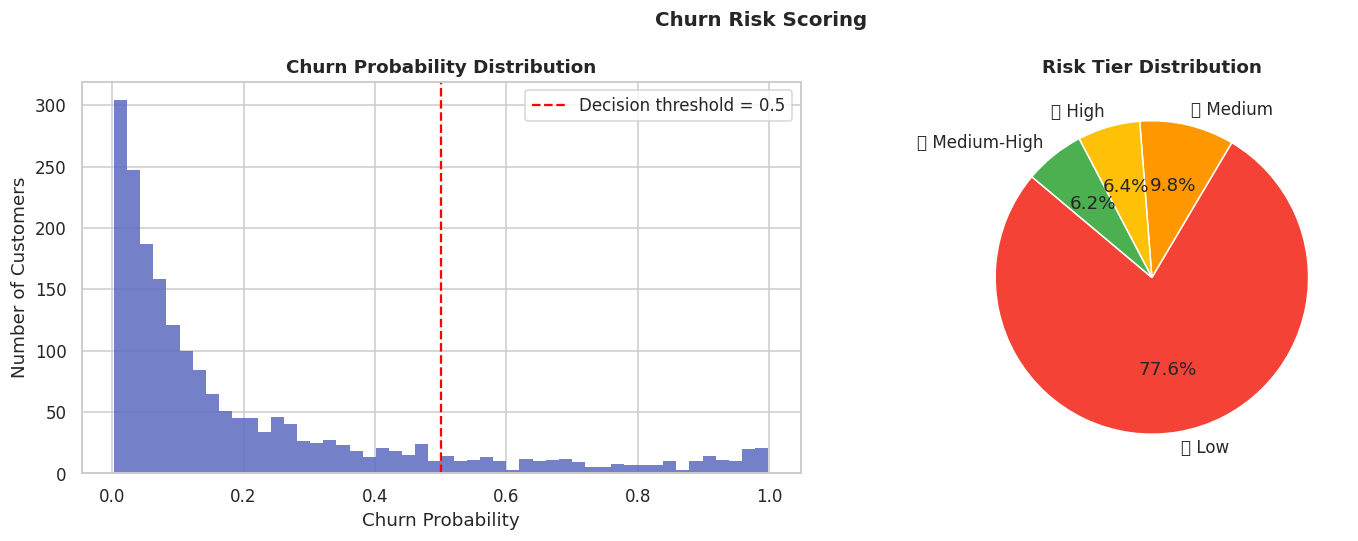

In [45]:
#  Risk Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
colors_hist = ['#4CAF50' if p < 0.5 else '#F44336' for p in churn_probs]
axes[0].hist(churn_probs, bins=50, color='#5C6BC0', edgecolor='none', alpha=0.85)
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold = 0.5')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Probability Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Risk Tier Pie
tier_counts = risk_df['RiskTier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#F44336', '#FF9800', '#FFC107', '#4CAF50'],
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Risk Tier Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Churn Risk Scoring', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# Top 20 High-Risk Customers
high_risk = risk_df.nlargest(20, 'ChurnProbability')[[
    'Age', 'Balance', 'NumOfProducts', 'IsActiveMember',
    'EstimatedSalary', 'ChurnProbability', 'RiskTier', 'ActualChurn'
]].reset_index(drop=True)

high_risk['ChurnProbability'] = high_risk['ChurnProbability'].round(3)
print('🔴 Top 20 Highest Churn-Risk Customers:')
high_risk

🔴 Top 20 Highest Churn-Risk Customers:


,Age,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,ChurnProbability,RiskTier,ActualChurn
0,58,133745.44,4,0,28373.86,0.998,🔴 High,1
1,57,112281.60,3,0,140225.14,0.995,🔴 High,1
2,46,115248.11,4,0,130752.01,0.993,🔴 High,1
3,52,139493.25,3,0,150093.32,0.992,🔴 High,1
4,61,62055.17,3,0,166305.16,0.991,🔴 High,1
5,44,105770.70,3,0,60533.96,0.991,🔴 High,1
6,50,130554.51,3,0,184758.17,0.991,🔴 High,1
7,56,50911.21,3,0,97629.31,0.990,🔴 High,1
8,45,131355.30,3,0,195395.33,0.989,🔴 High,1
9,51,154962.99,3,1,191932.27,0.989,🔴 High,1


In [47]:
# 5 Save scoring results to CSV
risk_df.to_csv('churn_risk_scores.csv', index=False)
print('✅ Risk scores saved to churn_risk_scores.csv')

# Download in Colab
from google.colab import files
files.download('churn_risk_scores.csv')

✅ Risk scores saved to churn_risk_scores.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

saving best model

In [48]:
import joblib

# Save model and scaler
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(FEATURE_NAMES, 'feature_names.pkl')

print(f'✅ Saved: best_churn_model.pkl ({best_model_name})')
print('✅ Saved: scaler.pkl')
print('✅ Saved: feature_names.pkl')

# Download all
from google.colab import files
for f in ['best_churn_model.pkl', 'scaler.pkl', 'feature_names.pkl']:
    files.download(f)

✅ Saved: best_churn_model.pkl (XGBoost)
✅ Saved: scaler.pkl
✅ Saved: feature_names.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
!pip install streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.0 MB/s eta 0:00:00


In [64]:
!npm install -g localtunnel --silent

In [65]:
 #  Start Streamlit in background
import subprocess, threading, time

proc = subprocess.Popen(
    ['python', '-m', 'streamlit', 'run', 'app.py', '--server.port=8501',
     '--server.headless=true'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(5)   # wait for server to start

In [66]:
#  Expose with localtunnel
tunnel = subprocess.Popen(
    ['npx', 'localtunnel', '--port', '8501'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)

output = tunnel.stdout.readline().decode()
print('🌐 Streamlit URL:', output.strip())
print('👆 Click the link above to open the app!')

🌐 Streamlit URL: your url is: https://funny-seas-deny.loca.lt
👆 Click the link above to open the app!


In [67]:
!pip install pyngrok -q

In [68]:
!ngrok authtoken PASTE_YOUR_NEW_TOKEN_HERE

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [69]:
!ngrok authtoken 2abc3def4ghi5jkl6mno_YOURREALTOKENHERE

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [70]:
!ngrok authtoken 3FEQgSFTBfD141ZhzPsaFPPhyTo_4PY3xsQVBZy3jn78u6JV8

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [71]:
from pyngrok import ngrok
import subprocess, threading

def run():
    subprocess.run(["streamlit", "run", "app.py",
                    "--server.port", "8501",
                    "--server.headless", "true"])

threading.Thread(target=run, daemon=True).start()

public_url = ngrok.connect(8501)
print("✅ Open this link:", public_url)

✅ Open this link: NgrokTunnel: "https://demeaning-purveyor-amulet.ngrok-free.dev" -> "http://localhost:8501"


In [72]:
import joblib

# Load the saved model
model = joblib.load('best_churn_model.pkl')
scaler = joblib.load('scaler.pkl')
features = joblib.load('feature_names.pkl')

print("Model loaded successfully!", model)

Model loaded successfully! XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


In [74]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('my_churn_project', 'zip', '/content')
files.download('my_churn_project.zip')